# 1.0 Comprension de los Datos

Corresponde a la seccion 7.2 de la monografia. Carga las 24 senales Drive
End (DE) del conjunto CWRU, verifica su calidad (NaN, infinitos,
duplicados, RPM disponible) y calcula los estadisticos descriptivos por
archivo (Tablas 1-3).

Toda la logica de carga vive en `rodamientos_module.dataset.CargadorCWRU`;
este notebook solo la invoca y presenta los resultados.


In [1]:
import sys
sys.path.insert(0, "..")

from rodamientos_module import config
from rodamientos_module.dataset import CargadorCWRU

cargador = CargadorCWRU(config.DIR_DATOS_RAW, config.ARCHIVOS_POR_CLASE)
registros = cargador.cargar_todos()

print(f"Archivos cargados: {len(registros)}")

Archivos cargados: 24


## Separacion del conjunto de test independiente (antes del EDA supervisado)

Respuesta a la observacion del docente: la seleccion de las variables
(RMS, skewness, kurtosis, factor de cresta, centroide espectral) se
habia justificado antes analizando figuras que comparaban clases sobre
los 24 archivos, incluyendo los 6 que luego se reservaban como test --
es decir, informacion de esos archivos influia indirectamente en la
seleccion de variables antes de que el test fuera realmente
independiente.

Para corregirlo, los 6 archivos de test (seccion 7.3.7) se separan aqui,
inmediatamente despues de cargar los datos crudos y antes de cualquier
analisis que compare clases. Las Tablas 1 y 2 que siguen son solo
verificacion de calidad de los datos crudos (NaN, infinitos, duplicados)
y no comparan clases ni influyen en la seleccion de variables, por lo que
se calculan sobre los 24 archivos. A partir de la Tabla 3 (estadisticos
descriptivos) y las Figuras 1 a 5, que si comparan clases para justificar
las variables, se usan unicamente los 18 archivos del conjunto de
ajuste. Los 6 archivos de test no se vuelven a inspeccionar hasta la
evaluacion final, una sola vez, en el notebook 4.0.

In [2]:
archivos_test = {a for lista in config.ARCHIVOS_TEST_FINAL.values() for a in lista}
registros_ajuste = [r for r in registros if r["archivo"] not in archivos_test]
registros_test = [r for r in registros if r["archivo"] in archivos_test]

print(f"Archivos de ajuste (se analizan en este notebook): {len(registros_ajuste)}")
print(f"Archivos reservados como test independiente (no se analizan aqui): {len(registros_test)}")
print("Archivos de test:", sorted(r["archivo"] for r in registros_test))

Archivos de ajuste (se analizan en este notebook): 18
Archivos reservados como test independiente (no se analizan aqui): 6
Archivos de test: ['100.mat', '105.mat', '118.mat', '130.mat', '144.mat', '156.mat']


## Tabla 1. Composicion del conjunto de datos seleccionado

(24 archivos completos, antes de separar el test; verificacion de calidad, no comparacion de clases.)

In [3]:
import pandas as pd

resumen_composicion = (
    pd.DataFrame([{"archivo": r["archivo"], "clase": r["clase"], "muestras": r["muestras"]} for r in registros])
    .groupby("clase")
    .agg(n_registros=("archivo", "count"), muestras_de=("muestras", "sum"))
    .reindex(config.ORDEN_CLASES)
)
resumen_composicion.loc["Total"] = resumen_composicion.sum()
resumen_composicion

,n_registros,muestras_de
clase,,
Normal,4,1698547
Ball,4,487093
Inner Race,4,488309
Outer Race,12,1465051
Total,24,4139000


## Tabla 2. Calidad y consistencia de los datos

Verificacion de valores NaN, infinitos, duplicados y disponibilidad de RPM
por archivo (seccion 7.2.2). Se realiza sobre los 24 archivos porque es
una verificacion de integridad, no una comparacion entre clases.

In [4]:
tabla_calidad = CargadorCWRU.tabla_calidad(registros)
tabla_calidad

,archivo,clase,muestras,nan_en_de,infinitos_en_de,rpm_disponible,duplicado
0,97.mat,Normal,243938,0,0,True,False
1,98.mat,Normal,483903,0,0,False,False
2,99.mat,Normal,485063,0,0,False,False
3,100.mat,Normal,485643,0,0,True,False
4,118.mat,Ball,122571,0,0,True,False
5,119.mat,Ball,121410,0,0,True,False
6,120.mat,Ball,121556,0,0,True,False
7,121.mat,Ball,121556,0,0,True,False
8,105.mat,Inner Race,121265,0,0,True,False
9,106.mat,Inner Race,121991,0,0,True,False


In [5]:
print("Total de NaN en las 24 senales DE:", tabla_calidad["nan_en_de"].sum())
print("Total de infinitos:", tabla_calidad["infinitos_en_de"].sum())
print("Archivos duplicados (hash identico):", tabla_calidad["duplicado"].sum())
print("Archivos sin RPM disponible:", (~tabla_calidad["rpm_disponible"]).sum())

Total de NaN en las 24 senales DE: 0
Total de infinitos: 0
Archivos duplicados (hash identico): 0
Archivos sin RPM disponible: 2


## Tabla 3. Estadisticos descriptivos de los registros de vibracion DE

Se calcula sobre los 24 archivos y se guarda para uso posterior (incluye
una verificacion diagnostica del notebook 4.0, ya realizada despues de
la evaluacion final). Para las Figuras 1 y 5, que comparan clases para
justificar variables, se recalcula una version restringida a los 18
archivos del conjunto de ajuste (`tabla_estadisticos_ajuste`).

In [6]:
tabla_estadisticos = CargadorCWRU.tabla_estadisticos_descriptivos(
    registros, fs=config.FRECUENCIA_MUESTREO
)
tabla_estadisticos_ajuste = CargadorCWRU.tabla_estadisticos_descriptivos(
    registros_ajuste, fs=config.FRECUENCIA_MUESTREO
)
tabla_estadisticos.round(4)

,archivo,clase,muestras,duracion_s,rpm,media,desv_estandar,rms,min,max
0,97.mat,Normal,243938,20.3282,1796.0,0.0126,0.0727,0.0738,-0.2866,0.3113
1,98.mat,Normal,483903,40.3252,NaN,0.0126,0.0652,0.0664,-0.3459,0.3175
2,99.mat,Normal,485063,40.4219,NaN,0.0123,0.0631,0.0643,-0.3269,0.3592
3,100.mat,Normal,485643,40.4702,1725.0,0.0125,0.0647,0.0659,-0.3065,0.2837
4,118.mat,Ball,122571,10.2142,1796.0,0.0126,0.1387,0.1392,-0.6070,0.6039
5,119.mat,Ball,121410,10.1175,1772.0,0.0039,0.1390,0.1391,-0.6596,0.6397
6,120.mat,Ball,121556,10.1297,1748.0,0.0046,0.1472,0.1473,-0.5667,0.6046
7,121.mat,Ball,121556,10.1297,1722.0,0.0042,0.1536,0.1536,-0.7206,0.6715
8,105.mat,Inner Race,121265,10.1054,1797.0,0.0134,0.2912,0.2915,-1.3799,1.7390
9,106.mat,Inner Race,121991,10.1659,1772.0,0.0058,0.2928,0.2929,-1.4030,1.5808


### Distribucion del RMS por condicion

Replica la Figura 1 de la monografia, calculada unicamente sobre los 18
archivos del conjunto de ajuste: se observa que la condicion Normal
presenta los valores de RMS mas bajos y mas homogeneos, mientras que
Outer Race muestra la mayor dispersion.

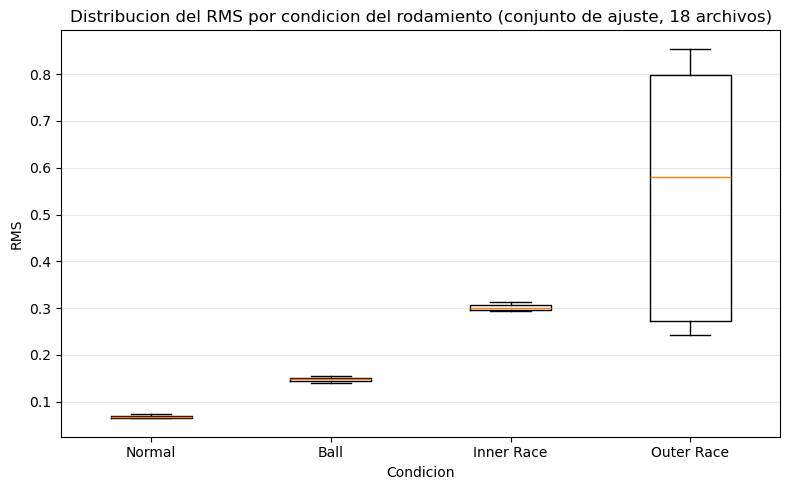

Figura guardada en reports/figures/fig01_distribucion_rms.png


In [7]:
import matplotlib.pyplot as plt

datos_rms = [
    tabla_estadisticos_ajuste.loc[tabla_estadisticos_ajuste["clase"] == clase, "rms"]
    for clase in config.ORDEN_CLASES
]

plt.figure(figsize=(8, 5))
plt.boxplot(datos_rms, tick_labels=config.ORDEN_CLASES)
plt.xlabel("Condicion")
plt.ylabel("RMS")
plt.title("Distribucion del RMS por condicion del rodamiento (conjunto de ajuste, 18 archivos)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/fig01_distribucion_rms.png", dpi=150)
plt.show()
print("Figura guardada en reports/figures/fig01_distribucion_rms.png")

### Guardado de la tabla de estadisticos

Se guarda la version de los 24 archivos en `data/interim/` (la usa el
notebook 4.0 para una verificacion diagnostica posterior a la evaluacion
final, no para seleccionar variables).

In [8]:
tabla_estadisticos.to_csv(config.DIR_DATOS_INTERIM / "estadisticos_descriptivos.csv", index=False)
tabla_calidad.to_csv(config.DIR_DATOS_INTERIM / "tabla_calidad.csv", index=False)
print("Tablas guardadas en data/interim/")

Tablas guardadas en data/interim/


### Figura 2. Comparacion temporal de las senales DE segun condicion

Se comparan los primeros 0.1 s de un registro representativo de cada
condicion, eligiendo unicamente archivos del conjunto de ajuste:
97.mat (Normal), 106.mat (Inner Race), 119.mat (Ball) y 131.mat (Outer
Race).

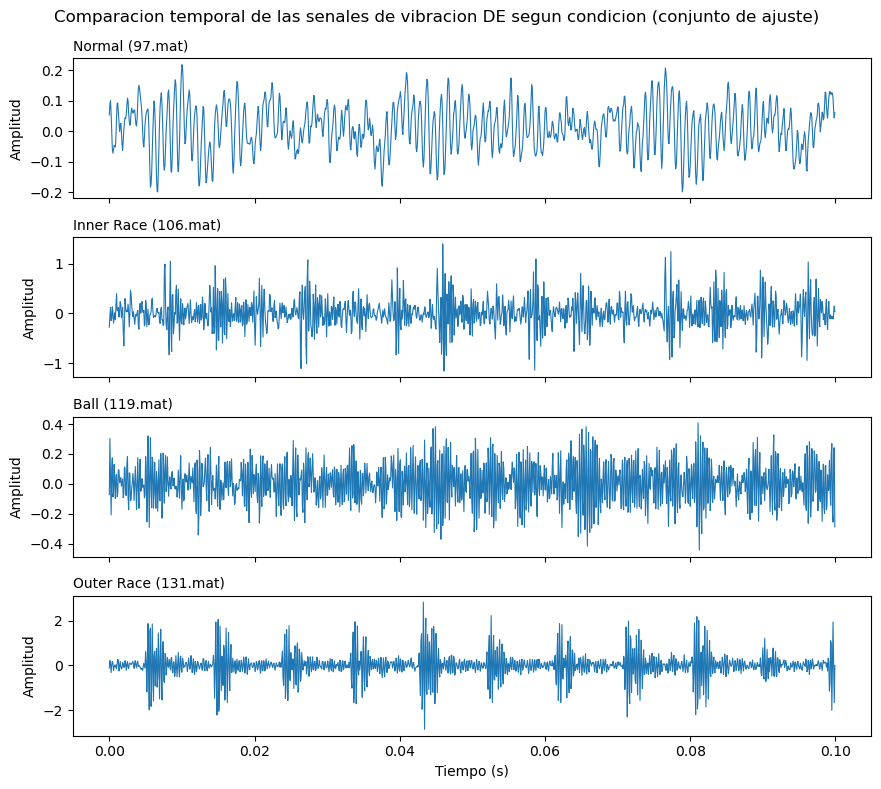

Figura guardada en reports/figures/fig02_comparacion_temporal.png


In [9]:
import numpy as np

registros_ajuste_por_archivo = {r["archivo"]: r for r in registros_ajuste}
representativos = {"Normal": "97.mat", "Inner Race": "106.mat", "Ball": "119.mat", "Outer Race": "131.mat"}
n_muestras = int(0.1 * config.FRECUENCIA_MUESTREO)

fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
for ax, (clase, archivo) in zip(axes, representativos.items()):
    senal = registros_ajuste_por_archivo[archivo]["senal"][:n_muestras]
    t = np.arange(len(senal)) / config.FRECUENCIA_MUESTREO
    ax.plot(t, senal, linewidth=0.8)
    ax.set_ylabel("Amplitud")
    ax.set_title(f"{clase} ({archivo})", fontsize=10, loc="left")
axes[-1].set_xlabel("Tiempo (s)")
fig.suptitle("Comparacion temporal de las senales de vibracion DE segun condicion (conjunto de ajuste)")
plt.tight_layout()
plt.savefig("../reports/figures/fig02_comparacion_temporal.png", dpi=150)
plt.show()
print("Figura guardada en reports/figures/fig02_comparacion_temporal.png")

### Figura 3. Comparacion espectral de las senales DE segun condicion

Se utiliza 1 s (12000 muestras) de cada registro representativo del
conjunto de ajuste, equivalente a una resolucion frecuencial de
aproximadamente 1 Hz.

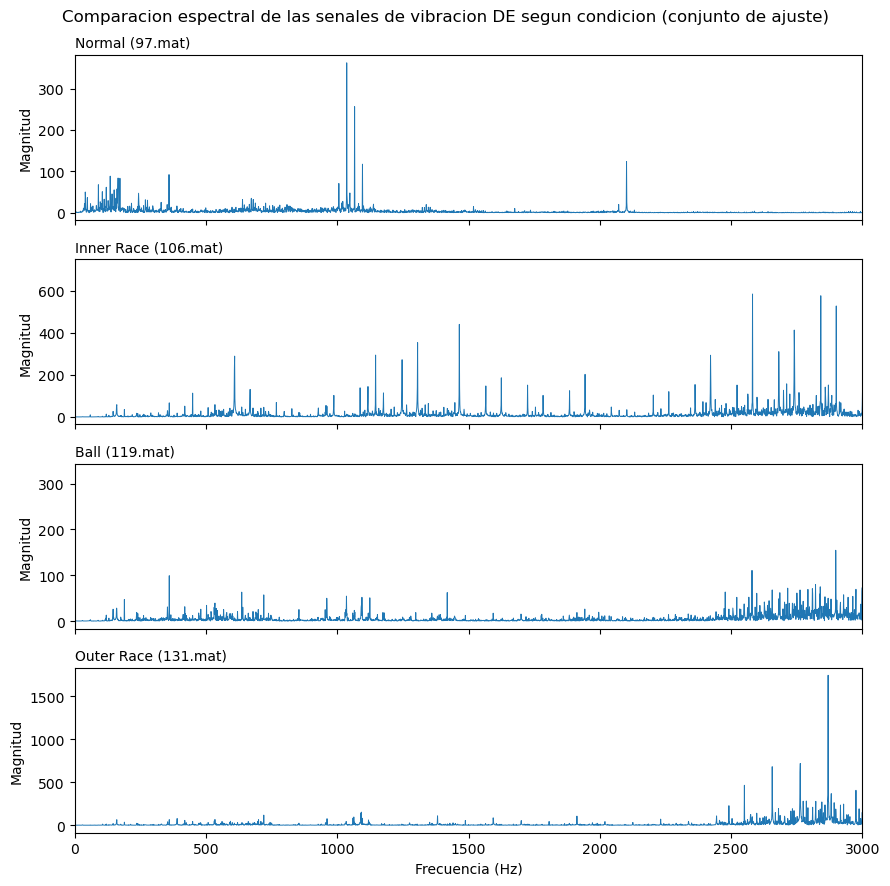

Figura guardada en reports/figures/fig03_comparacion_espectral.png


In [10]:
n_espectral = config.FRECUENCIA_MUESTREO  # 1 segundo

fig, axes = plt.subplots(4, 1, figsize=(9, 9), sharex=True)
for ax, (clase, archivo) in zip(axes, representativos.items()):
    senal = registros_ajuste_por_archivo[archivo]["senal"][:n_espectral]
    senal_c = senal - np.mean(senal)
    espectro = np.abs(np.fft.rfft(senal_c))
    frecs = np.fft.rfftfreq(len(senal_c), d=1 / config.FRECUENCIA_MUESTREO)
    ax.plot(frecs, espectro, linewidth=0.7)
    ax.set_ylabel("Magnitud")
    ax.set_xlim(0, 3000)
    ax.set_title(f"{clase} ({archivo})", fontsize=10, loc="left")
axes[-1].set_xlabel("Frecuencia (Hz)")
fig.suptitle("Comparacion espectral de las senales de vibracion DE segun condicion (conjunto de ajuste)")
plt.tight_layout()
plt.savefig("../reports/figures/fig03_comparacion_espectral.png", dpi=150)
plt.show()
print("Figura guardada en reports/figures/fig03_comparacion_espectral.png")

### Figura 4. Espectro de la envolvente del registro 106.mat (conjunto de ajuste)

Se calcula mediante la transformada de Hilbert (demodulacion de
amplitud) y se comparan las frecuencias caracteristicas del rodamiento
SKF 6205-2RS JEM (BPFO, BPFI, BSF, FTF), calculadas a partir de la RPM
del registro. Se usa 106.mat (Inner Race, conjunto de ajuste) en lugar
de 105.mat, que es uno de los 6 archivos reservados como test.

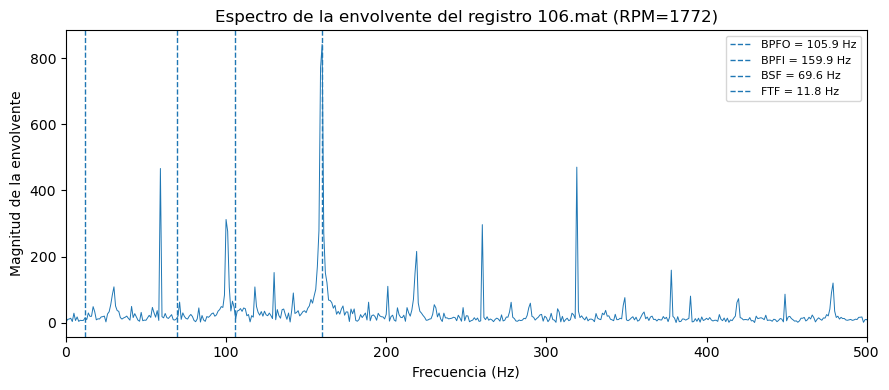

Frecuencias caracteristicas: {'BPFO': 105.87, 'BPFI': 159.93, 'BSF': 69.6, 'FTF': 11.76}


In [11]:
from rodamientos_module.eda import analisis as eda

registro_106 = registros_ajuste_por_archivo["106.mat"]
senal_106 = registro_106["senal"][:n_espectral]
frecs_env, espectro_env = eda.envolvente_espectro(senal_106, fs=config.FRECUENCIA_MUESTREO)
frecs_carac = eda.frecuencias_caracteristicas(registro_106["rpm"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(frecs_env, espectro_env, linewidth=0.7)
for nombre, freq in frecs_carac.items():
    ax.axvline(freq, linestyle="--", linewidth=1, label=f"{nombre} = {freq:.1f} Hz")
ax.set_xlim(0, 500)
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("Magnitud de la envolvente")
ax.set_title(f"Espectro de la envolvente del registro 106.mat (RPM={registro_106['rpm']:.0f})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/fig04_envolvente_105.png", dpi=150)
plt.show()
print("Frecuencias caracteristicas:", {k: round(v, 2) for k, v in frecs_carac.items()})

### Figura 5. Relacion entre RPM y RMS segun la condicion del rodamiento

Se utilizan los registros del conjunto de ajuste que disponen de RPM
identificable (98.mat y 99.mat se excluyen por no tener RPM).

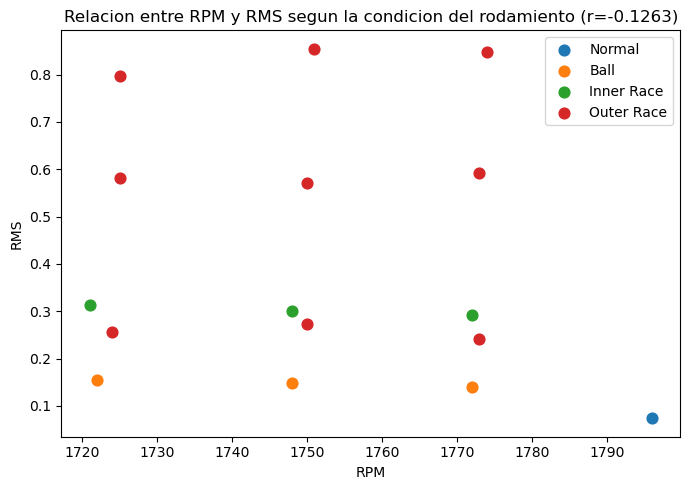

Correlacion RPM-RMS: r = -0.1263 (n=16 registros del conjunto de ajuste con RPM disponible)


In [12]:
tabla_rpm = tabla_estadisticos_ajuste.dropna(subset=["rpm"])
r = tabla_rpm["rpm"].corr(tabla_rpm["rms"])

fig, ax = plt.subplots(figsize=(7, 5))
for clase in config.ORDEN_CLASES:
    sub = tabla_rpm[tabla_rpm["clase"] == clase]
    ax.scatter(sub["rpm"], sub["rms"], label=clase, s=60)
ax.set_xlabel("RPM")
ax.set_ylabel("RMS")
ax.set_title(f"Relacion entre RPM y RMS segun la condicion del rodamiento (r={r:.4f})")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/fig05_rpm_vs_rms.png", dpi=150)
plt.show()
print(f"Correlacion RPM-RMS: r = {r:.4f} (n={len(tabla_rpm)} registros del conjunto de ajuste con RPM disponible)")